# Graphical Neuronal Network for TSP (ELU)

* Autor: *Pablo Mendieta Ruiz*








## 2. Código del Algoritmo

**Importación de librerias**

In [1]:
# Llamadas a función de otros archivos, que serán utilizados en el código. (explicados en sus respectivos archivos .py)
import dataset
import importlib
importlib.reload(dataset)
from dataset import DatasetCreation, FamousTSP

import solutions
importlib.reload(solutions)
from solutions import SolutionAnalysys, Opt

import inicializacion_pesos
importlib.reload(inicializacion_pesos)
from inicializacion_pesos import apply_init

In [2]:
# Librerías necesarias 
import numpy as np 
import random
from typing import Optional, Tuple
import matplotlib.pyplot as plt
import os
import gc
import pandas as pd
import itertools
from torchinfo import summary
import networkx as nx

# Pytorch 
import torch
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from torch.nn import Sequential as Seq, Linear as Lin, ReLU, BatchNorm1d, ELU
from torch_geometric.utils import scatter
from torch_geometric.nn import MetaLayer
from torch import Tensor

### 2.1. Carga de datos y preprocesamiento 

La base de datos ha sido generada en el archivo *creacion_dataset.py*. Consta de 1000 problemas TSP, de 5, 10, 12 y 15 nodos. Estos problemas son creados con la siguente estructura (explicada en el archivo *crecion_dataset.py*) para su posterior implementación en la GNN. 


In [3]:
# descarga de la Base de Datos 
data_list = torch.load("TSP_data/tsps1000.pt", weights_only=False)

In [4]:
# Estructura de un TSP de la base de datos: 

ejemplo = data_list[0] # Ejemplo de un TSP de 5 nodos

print("Nodos del problema:")
print(ejemplo.x.tolist())
print("\nAristas por donde pasa el tour (1 si para , 0 si no pasa):")
print(ejemplo.y.tolist())
print("\nCamino más corto")
print(ejemplo.true_path.tolist())
print("\nDistancia total del tour:")
print(ejemplo.true_distance.tolist()[0][0])
print("\nPeso para la red neuronal:")
print(ejemplo.pos_class_weight)

Nodos del problema:
[[40.72846603393555, 33.576290130615234], [71.94888305664062, 11.545259475708008], [68.049560546875, 6.516124725341797], [66.26758575439453, 37.31504821777344], [63.9853515625, 11.13711166381836]]

Aristas por donde pasa el tour (1 si para , 0 si no pasa):
[[0.0], [0.0], [0.0], [1.0], [0.0], [0.0], [0.0], [1.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [1.0], [0.0], [1.0], [0.0], [0.0], [0.0], [1.0], [0.0], [0.0], [0.0], [0.0]]

Camino más corto
[0.0, 3.0, 1.0, 2.0, 4.0]

Distancia total del tour:
97.0348129272461

Peso para la red neuronal:
4.0


Separación de la base de datos en Train: 70%, Test: 20% y Val: 10%

In [5]:
tamanio = len(data_list) # tamaño de la base de datos 

train_len = int(tamanio * 0.7) # 70 % para train
val_len = int(tamanio * 0.1) # 10 % para val 

mezclar_datos = random.sample(data_list, len(data_list)) # Mezcla de la base de datos 

lista_train = mezclar_datos[:train_len]
lista_val = mezclar_datos[train_len:train_len + val_len]
lista_test = mezclar_datos[train_len + val_len:] # 20 % para test 

Creación de lotes de datos, con *train_list*, *val_list* y *test_list*. Cada lote contiene problemas del mismo tamaño, para facilitar a la GNN el entrenamiento.

In [6]:
max_batch = 256  
train_data = []

# Ordena train_list por tamaño de nodos 
orden_datos = sorted(lista_train, key=lambda x: x.num_nodes)

for dataset in orden_datos:
    if not train_data or train_data[-1][-1].num_nodes != dataset.num_nodes:
        # Batch vacío o número de nodos diferentes, se crea otro batch
        train_data.append([dataset])
    else:
        # Batch de mismo número de nodos y con espacio, añade el TSP
        batch_actual = train_data[-1]
        if sum(data.num_nodes for data in batch_actual) + dataset.num_nodes <= max_batch:
            batch_actual.append(dataset)
        else:
            # Si no tiene espacio, crea otro batch
            train_data.append([dataset])

# Mismo procedimiento para los datos de validación 
val_data = []
orden_datos = sorted(lista_val, key=lambda x: x.num_nodes)

for dataset in orden_datos:
    if not val_data or val_data[-1][-1].num_nodes != dataset.num_nodes:
        val_data.append([dataset])
    else:
        batch_actual = val_data[-1]
        if sum(data.num_nodes for data in batch_actual) + dataset.num_nodes <= max_batch:
            batch_actual.append(dataset)
        else:
            val_data.append([dataset])


# Mismo procedimiento para los datos de test
test_data = []
orden_datos = sorted(lista_test, key=lambda x: x.num_nodes)

for dataset in orden_datos:
    if not test_data or test_data[-1][-1].num_nodes != dataset.num_nodes:
        test_data.append([dataset])
    else:
        batch_actual = test_data[-1]
        if sum(data.num_nodes for data in batch_actual) + dataset.num_nodes <= max_batch:
            batch_actual.append(dataset)
        else:
            test_data.append([dataset])

# Creación de los generadores de datos 
train_generador = DataLoader(train_data, batch_size=None, shuffle=True)
val_generador= DataLoader(val_data, batch_size=None, shuffle=True)
test_generador = DataLoader(test_data, batch_size=None, shuffle=True)
            

### 2.2 Creación de la GNN 

En este apartado están definifidas las funciones y capas necesarias para la creación y entrenamiento de la GNN. 

* la clase **Aristas** se encarga de actualizar los embeddings de cada arista en función de: 

    - El embedding del nodo origen. 
    - El embedding del nodo destino.
    - El embedding previo de la propia arista.

Para ello concatena los 3 embeddings y aplica un Multilayer Perceptron (MLP), junto con un sesgo de las características previas de la arista, genera la nueva representación de esta. 

In [7]:
class Aristas(torch.nn.Module):
    def __init__(self,hidden_dim):
        super().__init__()
        # Multiplicamos el vector por 3 debido a que es una concatenación de 3 vectores de la info de cada nodo: 
        #  1. src: Representación del nodo origen. 
        #  2. dst: Representación del nodo destino. 
        #  3. arista_emb: atributos actuales de la arista. 
        dimension = ( 3 * hidden_dim )

        # Red Neuronal pequeña, de una capa: BatchNorm1d(3 * hidden_dim) -> Relu() -> Linear(hidden_dim)
        self.edge_mlp = Seq(BatchNorm1d(dimension),
                            ELU(),
                            Lin(dimension, hidden_dim,bias=False))

    # Actualiza la información de los nodos 
    def forward(self, src, dst, arista_emb, peso_arista,  batch):
        out = torch.cat([src, arista_emb,dst], 1)

        return self.edge_mlp(out) + arista_emb # transforma la arista usando MLP y lo suma a la representación original.
    

* La clase **Nodos** sse encarga de actualizar los valores de los nodos de cada problema. Toma para casda nodo los embeddings de sus vecinos y las característcas de las aristas que los unen.

    - El MLP 1: Calcula el mensaje que cada arista envía desde su nodo origen hacia el nodo destino. 
    - El MLP 2: Junto con el embbeding del nodo, más el mensaje de los nodos vecinos (MLP 1), genera la nueva representación del nodo. 
    

In [8]:
class Nodos(torch.nn.Module):
    def __init__(self,hidden_dim):
        super().__init__()
        # Concatena 2 vectores de tamaño hidden_dim. 
        # Caso mlp1:  
        #  1. x[row]: representación del nodo origen de cada arista. 
        #  2. arista_emb: representación de la arista. 
        # Caso mlp2: 
        #  1. x: representación original del nodo. 
        #  2. out: vector de agregar los mensajes de los nodos vecinos (MLP 1).

        dimension = ( 2 * hidden_dim)

        
        self.node_mlp_1 = Seq(BatchNorm1d(dimension),
                              ELU(),
                              Lin(dimension, hidden_dim)
                              )
        self.node_mlp_2 = Seq(BatchNorm1d(dimension),
                              ELU(),
                              Lin(dimension, hidden_dim))

    def forward(self, x, edge_index, arista_emb, peso_arista, batch):
        # x: Representación de los nodos
        # edge_index: qué nodos están conectados 
        # arista_emb: Representación de las aristas 
        # peso_arista: Peso de cada arista 

        # Nodos de origen y destino 
        row, col = edge_index

        '''Información agragada desde nodos vecinos '''
        # Calcula el mensaje que manda el nodo origen al nodo destino. 
        out = torch.cat([x[row], arista_emb], dim=1)
        out = self.node_mlp_1(out)

        # Junta todos los mensajes que le llegan al nodo destino y hace una media ponderada. 
        out = scatter(peso_arista*out, col, dim=0, dim_size=x.size(0), reduce='mean')
        out = torch.cat([x, out], dim=1)

        return self.node_mlp_2(out) + x

* La clase **Update**  agrupa en una sola capa, la lógica de "mensaje - agregado - actualización" en aristas, nodos y grafo completo (usando las anteriores clases)

In [9]:
class Update(torch.nn.Module):

    # Llamadas a los módulos explicados antes 
    def __init__(self,edge_model,node_model):
        super(Update, self).__init__()
        self.edge_model = edge_model
        self.node_model = node_model

    def forward(
        self,
        x: Tensor,
        edge_index: Tensor,
        arista_emb: Optional[Tensor] = None,
        peso_arista: Optional[Tensor] = None,
        batch: Optional[Tensor] = None,
    ) -> Tuple[Tensor, Optional[Tensor], Optional[Tensor]]:

        row = edge_index[0]
        col = edge_index[1]

        # Calcular los nuevos atributos de las aristas
        if self.edge_model is not None:
            arista_emb = self.edge_model(x[row], x[col], arista_emb, peso_arista, batch if batch is None else batch[row])

        # Actuliza los nodos, en función de: estado actual, mensajes de vecinos(aristas), contexto global
        if self.node_model is not None:
            x = self.node_model(x, edge_index, arista_emb, peso_arista, batch)

        return x, arista_emb,  # nodos, aristas y vector del grafo completo 

* La clase **GNN** es la estructura completa de la **GNN**, donde podemos oberservar las capas de la red: 

    - Preprocesamiendto de los nodos
    - Dos capas de propagración de mensajes: Metalayer
    - Decodificador para predecir si la arista pertenece al tour 
    - Capa finala para puntuar cada arista

In [22]:
class GNN(torch.nn.Module):

    # Transfromación de los datos 
    def __init__(self,node_input_dim, edge_input_dim, hidden_dim, decoder, use_edge_weight=True):
        super(GNN, self).__init__()
        self.lin0_edge = Seq(Lin(edge_input_dim, hidden_dim,bias=False),
                             BatchNorm1d(hidden_dim),
                             ELU()) 
        
        self.lin0_node = Seq(Lin(node_input_dim, hidden_dim,bias=False),
                             BatchNorm1d(hidden_dim),
                             ELU())

        # Decodifadores 
        self.edge_lin1 = Lin((hidden_dim), hidden_dim) # embeddings de aristas 
        self.node_lin1 = Lin((hidden_dim*2), hidden_dim) # embeddings de nodos 
        self.nodes_edge_lin1 = Lin((hidden_dim*3), hidden_dim) # nodo1 + arista + nodo2
        self.lin2 = Lin(hidden_dim, 1) #Salida final

        # Parámetros de Control 
        self.decoder = decoder 
        self.use_edge_weight=use_edge_weight # Pesos de las aristas 

        '''Capas de Update'''
        self.metalayer = Update(Aristas(hidden_dim), Nodos(hidden_dim))
        self.metalayer2 = Update(Aristas(hidden_dim), Nodos(hidden_dim))
        self.metalayer3 = Update(Aristas(hidden_dim), Nodos(hidden_dim))


    def forward(self, x, edge_index, arista_emb, peso_arista, batch):
        arista_emb = self.lin0_edge(arista_emb)
        x = self.lin0_node(x)

        # Normalización de datos 
        if self.use_edge_weight==True and peso_arista is not None:
            peso_arista = torch.ones(arista_emb.shape[0],1)

        # Propagación de mensajes 
        x, arista_emb = self.metalayer(x, edge_index, arista_emb, peso_arista, batch)
        x, arista_emb = self.metalayer2(x, edge_index, arista_emb, peso_arista, batch)
        x, arista_emb = self.metalayer3(x, edge_index, arista_emb, peso_arista, batch)

        # En función delvalor de self.decoder, se decide cómo predecir si una arista está en el tour 
        if self.decoder=='edge_nodes_emb': # combina nodos y aristas 
            row, col = edge_index
            z = torch.cat([x[row], arista_emb, x[col]], dim=-1)
            out = self.nodes_edge_lin1(z)

        else:
            raise ValueError('Possible decoder is edge_nodes_emb')

        if "inner_product" not in self.decoder:
            out = self.lin2(out)

        return out

**Estructura de la Red Neuronal Gráfica**

Una vez ya explicadas todas las clases necesarias, se procede a la creación de la Red Neuronal Gráfica, en este caso, para poder imprimirla y ver la estructura de la misma. Se van a añadir unos hiperparámetros de ejemplo: 

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === PARÁMETROS DEL MODELO ===
node_input_dim = 2
edge_input_dim = 1
hidden_dim = 128
use_edge_weight = True
num_epochs = 32

# === INSTANCIAR MODELO ===
model = GNN(node_input_dim=node_input_dim,
                             edge_input_dim=edge_input_dim,
                             hidden_dim=hidden_dim,
                             decoder="edge_nodes_emb",  
                             use_edge_weight=use_edge_weight
                            )

# Inicialización de pesos
apply_init(model, 'he')

model.to(device)

optimizador = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

criterion = torch.nn.BCEWithLogitsLoss(reduction='none')

pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of parameters: {pytorch_total_params}')

# === CREAR ENTRADAS DE EJEMPLO ===
num_nodes = 12
num_edges = num_nodes * (num_nodes - 1)  # grafo dirigido completo

x = torch.rand((num_nodes, node_input_dim))
edge_index = torch.tensor(list(itertools.permutations(range(num_nodes), 2)), dtype=torch.long).T
arista_emb = torch.rand((num_edges, edge_input_dim))
peso_arista = torch.ones((num_edges, 1))
batch = torch.zeros(num_nodes, dtype=torch.long)

# === MOSTRAR ESTRUCTURA DEL MODELO ===

summary(
    model,
    input_data=(x, edge_index, arista_emb, peso_arista, batch),
    depth=4,           
    col_names=["input_size", "output_size", "num_params"],
    col_width=20,
    row_settings=["var_names"]
)

Number of parameters: 449921


Layer (type (var_name))                  Input Shape          Output Shape         Param #
GNN (GNN)                                [12, 2]              [132, 1]             49,408
├─Sequential (lin0_edge)                 [132, 1]             [132, 128]           --
│    └─Linear (0)                        [132, 1]             [132, 128]           128
│    └─BatchNorm1d (1)                   [132, 128]           [132, 128]           256
│    └─ELU (2)                           [132, 128]           [132, 128]           --
├─Sequential (lin0_node)                 [12, 2]              [12, 128]            --
│    └─Linear (0)                        [12, 2]              [12, 128]            256
│    └─BatchNorm1d (1)                   [12, 128]            [12, 128]            256
│    └─ELU (2)                           [12, 128]            [12, 128]            --
├─Update (metalayer)                     [12, 128]            [12, 128]            --
│    └─Aristas (edge_model)              

* La función **train** se encarga del entrenamiendo del modelo, siendo de las más complejas. Sus funciones son las siguientes: 

    1. Para cada batch(lote):
        - Llama a la GNN para obtener la variable *out* (puntuación de cada arista).
        - Calcula la péridida binaria por arista. 
        - Construye un vector de pesos que penaliza a las aristas positivas. 
        - Reconstruye "mapas de calor" de predicciones y rutas para cada grafo. 
        - Calcula las métricas L1 de "distancia al tour óptimo" y "gap porcentual". 
    
    2. Valores de salida: 
        - valor de pérdida.
        - Promedio de la métrica L1 de distancia. 
        - Promedio del gap. 



In [24]:
def train(train_generador):

    model.train() # Modo de entrenamiento 
    l1_path_distances = 0 # Suma de las distancias promedio del tour
    l1_optimality_gaps = 0 # sua de los gap (qué tan lejos está del tour óptimo)

    for train_data in train_generador:  # Iterate in batches over the training dataset.
        train_data.x = train_data.x.to(device)
        train_data.edge_index= train_data.edge_index.to(device)
        train_data.edge_attr = train_data.edge_attr.to(device)
        train_data.edge_weight = train_data.edge_weight.to(device)
        train_data.batch = train_data.batch.to(device)
        out = model(train_data.x, train_data.edge_index,train_data.edge_attr, train_data.edge_weight, train_data.batch)
        train_loss = criterion(out, train_data.y.to(device))  # Compute the loss.

        batch_weights = torch.ones(train_loss.shape)

        mask = train_data.y.bool()  # Add a dimension to match the shape of ones_tensor
        batch_weights[mask.squeeze()] *= train_data.pos_class_weight[0]

        train_loss = train_loss * batch_weights.to(device)
        train_loss = train_loss.sum() / batch_weights.sum()

        train_loss.backward()  # Derive gradients.
        optimizador.step()  # Update parameters based on gradients.
        optimizador.zero_grad()  # Clear gradients.

        for_view = int(train_data.num_nodes/train_data.num_graphs)
        batch_out_heat_map=out.view((train_data.num_graphs, for_view,for_view))
        batch_truth_heat_map=train_data.true_path.view((train_data.num_graphs, for_view))
        batch_peso_arista=train_data.edge_weight.view((train_data.num_graphs, for_view, for_view))
        batch_true_distancess =  train_data.true_distance.view((train_data.num_graphs))

        l1_path_distance, l1_gap = SolutionAnalysys.mean_per_batch_optimality_metrics(batch_out_heat_map, batch_truth_heat_map, train_data.num_graphs, for_view, batch_peso_arista, batch_true_distancess)
        l1_path_distances += l1_path_distance
        l1_optimality_gaps += l1_gap

    return train_loss, l1_path_distances/len(train_generador), l1_optimality_gaps/len(train_generador)


* La función **test** se encarga de evaluar al modelo. Para ello, recorre los lotes de test, calculando: 

    1. Test_loss: pérdida del último *batch* procesado. 
    2. La distancia L1 promedio entre tour predicho y tour óptimo. 
    3. El gap de optimalidad promedio. 

In [25]:
import torch
from sklearn.metrics import precision_score, recall_score, roc_auc_score
import networkx as nx

def test(loader, threshold=0.5):
    model.eval()
    total_loss = 0.0
    l1_path_distances = 0.0
    l1_optimality_gaps = 0.0

    # Para métricas de clasificación
    all_probs = []
    all_labels = []

    # Para tour length
    total_tour_len = 0.0
    total_graphs = 0

    for data in loader:
        # — Mover datos a device —
        for attr in [
            'x','edge_index','edge_attr','edge_weight',
            'batch','y','true_path','true_distance',
            'pos_class_weight'
        ]:
            setattr(data, attr, getattr(data, attr).to(device))

        # — Forward y loss con pesos de clase —
        out = model(
            data.x,
            data.edge_index,
            data.edge_attr,
            data.edge_weight,
            data.batch
        )
        loss_raw = criterion(out, data.y)
        weights = torch.ones_like(loss_raw)
        mask = data.y.bool().squeeze()
        weights[mask] *= data.pos_class_weight[0]
        loss = (loss_raw * weights).sum() / weights.sum()
        total_loss += loss.item()

        # — Métricas de optimalidad (todos torch.Tensor) —
        B = data.num_graphs
        V = int(data.num_nodes / B)
        out_map    = out.view(B, V, V).cpu().detach()         
        truth_map  = data.true_path.view(B, V).cpu().detach()
        edge_wmat  = data.edge_weight.view(B, V, V).cpu().detach()
        true_dists = data.true_distance.view(B).cpu().detach()

        l1_dist, l1_gap = SolutionAnalysys.mean_per_batch_optimality_metrics(
            out_map, truth_map, B, V, edge_wmat, true_dists
        )
        l1_path_distances  += l1_dist
        l1_optimality_gaps += l1_gap

        # — Acumular para clasificación —
        probs  = torch.sigmoid(out).cpu().detach().view(-1)
        labels = data.y.cpu().detach().view(-1)
        all_probs.append(probs)
        all_labels.append(labels)

        # — Reconstruir tour y suma de longitudes —
        for b in range(B):
            G = nx.Graph()
            G.add_nodes_from(range(V))
            mat_prob = out_map[b]
            mat_w     = edge_wmat[b]

            for i in range(V):
                for j in range(i+1, V):
                    G.add_edge(
                        i, j,
                        weight=mat_w[i, j].item(),
                        prob=mat_prob[i, j].item()
                    )

            tour = list(nx.approximation.greedy_tsp(G, weight='weight'))

            # Intentamos sumar la longitud, o fallback a true_dists
            tour_len = 0.0
            cyclic = tour[1:] + [tour[0]] if len(tour) > 1 else []
            for u, v in zip(tour, cyclic):
                if G.has_edge(u, v):
                    tour_len += G[u][v]['weight']
                else:
                    # Si falta la arista, usamos la distancia real como fallback
                    tour_len = true_dists[b].item()
                    break

            total_tour_len += tour_len
            total_graphs   += 1

    # — Cálculo final de métricas de clasificación —
    all_probs  = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    precision  = precision_score(
        all_labels, (all_probs > threshold).astype(int)
    )
    recall     = recall_score(
        all_labels, (all_probs > threshold).astype(int)
    )
    auc        = roc_auc_score(all_labels, all_probs)
    avg_tour_len = total_tour_len / total_graphs

    N = len(loader)
    return (
        total_loss/N,
        l1_path_distances/N,
        l1_optimality_gaps/N,
        precision,
        recall,
        auc,
        avg_tour_len
    )

### 2.3 Entrenamiento de la GNN

Se va a entrenar el modelo, y guardar información del mismo de cada época para su posterior análisis.

In [14]:
train_losses = []
val_losses   = []
test_losses  = []

train_l1_opt_gaps = []
val_l1_opt_gaps   = []
test_l1_opt_gaps  = []

val_precisions = []
val_recalls    = []
val_aucs       = []
val_tour_lens  = []

for epoch in range(num_epochs+1):
    # — Entrenamiento —
    train_loss, train_l1, train_gap = train(train_generador)

    # — Validación —
    (val_loss,
     val_l1,
     val_gap,
     val_prec,
     val_rec,
     val_auc,
     val_tour_len) = test(val_generador)

    # — Test final (solo loss/L1/gap) —
    test_loss, test_l1, test_gap = test(test_generador)[:3]

    # — Impresión cada 5 epochs —
    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d}")
        print(f"\tTrain loss: {train_loss:.4f}  L1: {train_l1:.4f}  gap: {train_gap:.4f}")
        print(f"\tVal   loss: {val_loss:.4f}  L1: {val_l1:.4f}  gap: {val_gap:.4f}")
        print(f"\t       Prec: {val_prec:.4f}  Rec: {val_rec:.4f}  AUC: {val_auc:.4f}")
        print(f"\tTest  loss: {test_loss:.4f}  L1: {test_l1:.4f}  gap: {test_gap:.4f}\n")

    # — Almacenamiento para graficar después —
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)

    train_l1_opt_gaps.append(train_gap)
    val_l1_opt_gaps.append(val_gap)
    test_l1_opt_gaps.append(test_gap)

    val_precisions.append(val_prec)
    val_recalls.append(val_rec)
    val_aucs.append(val_auc)
    val_tour_lens.append(val_tour_len)


Epoch 000
	Train loss: 0.5382  L1: 7.1901  gap: 0.1581
	Val   loss: 0.5752  L1: 5.7221  gap: 0.0951
	       Prec: 0.1888  Rec: 0.8169  AUC: 0.7900
	Test  loss: 0.5524  L1: 6.7385  gap: 0.0984

Epoch 005
	Train loss: 0.5349  L1: 7.0274  gap: 0.1667
	Val   loss: 0.5717  L1: 5.6288  gap: 0.0954
	       Prec: 0.2047  Rec: 0.7689  AUC: 0.7950
	Test  loss: 0.5419  L1: 5.9935  gap: 0.0920

Epoch 010
	Train loss: 0.3896  L1: 6.7987  gap: 0.1457
	Val   loss: 0.5002  L1: 5.7418  gap: 0.1201
	       Prec: 0.2538  Rec: 0.8041  AUC: 0.8544
	Test  loss: 0.4674  L1: 6.4469  gap: 0.1237

Epoch 015
	Train loss: 0.3653  L1: 6.4316  gap: 0.1282
	Val   loss: 0.4839  L1: 5.2749  gap: 0.0891
	       Prec: 0.2693  Rec: 0.8214  AUC: 0.8724
	Test  loss: 0.4458  L1: 5.9489  gap: 0.1015

Epoch 020
	Train loss: 0.4040  L1: 6.1271  gap: 0.1211
	Val   loss: 0.4664  L1: 5.3936  gap: 0.1064
	       Prec: 0.2748  Rec: 0.8254  AUC: 0.8726
	Test  loss: 0.4399  L1: 6.4087  gap: 0.1261

Epoch 025
	Train loss: 0.3515  L1: 

**Gráficas de información del modelo**

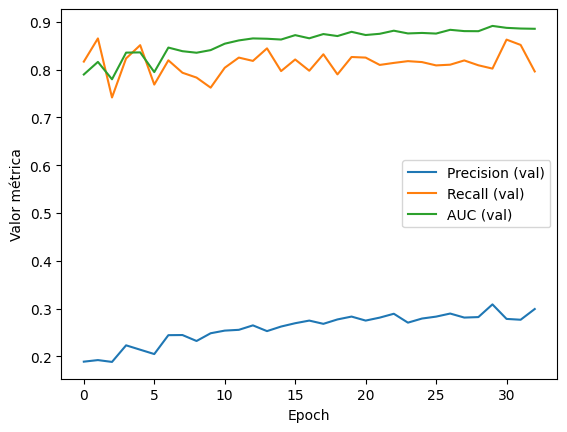

In [15]:
import matplotlib.pyplot as plt

plt.plot(val_precisions, label="Precision (val)")
plt.plot(val_recalls,    label="Recall (val)")
plt.plot(val_aucs,       label="AUC (val)")
plt.xlabel("Epoch")
plt.ylabel("Valor métrica")
plt.legend()
plt.show()

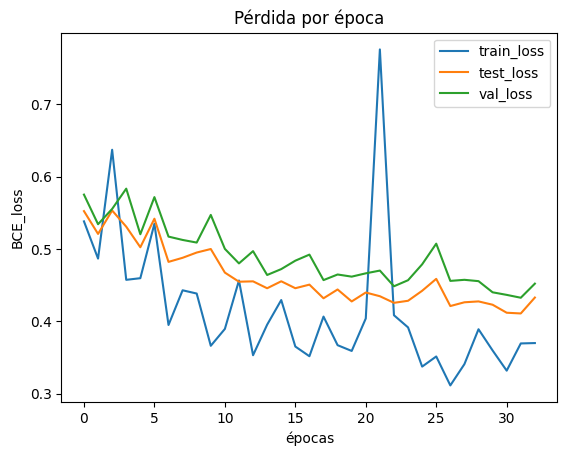

In [16]:
# Asegurarnos de que cada valor sea un float
train_vals = [t.item() if hasattr(t, 'item') else float(t) for t in train_losses]
val_vals   = [t.item() if hasattr(t, 'item') else float(t) for t in val_losses]
test_vals  = [t.item() if hasattr(t, 'item') else float(t) for t in test_losses]

plt.plot(train_vals, label='train_loss')
plt.plot(test_vals,  label='test_loss')
plt.plot(val_vals,   label='val_loss')
plt.xlabel('épocas')
plt.ylabel('BCE_loss')
plt.title('Pérdida por época')
plt.legend()
plt.show()


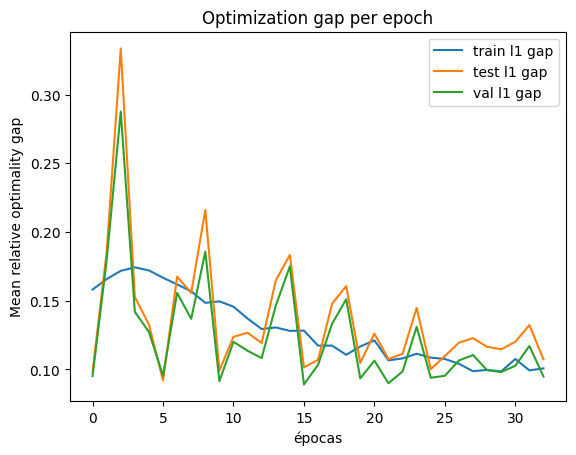

In [17]:
# Gráfica de porcentaje de gap medio por época
plt.plot(train_l1_opt_gaps,label='train l1 gap')
plt.plot(test_l1_opt_gaps,label='test l1 gap')
plt.plot(val_l1_opt_gaps,label='val l1 gap')
plt.xlabel('épocas')
plt.ylabel('Mean relative optimality gap')
plt.title("Optimization gap per epoch")
plt.legend()
plt.show()

**Búsqueda de Hiperparámetros**

Una vez visto cómo fuciona la red neuronal, se va a hacer un entrenamiento de varios modelos, modficando los hiperparámetros para posteriormente compararlos y continuar el proceso con el que mejor resultados dé. 

In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Parámetros fijos ===
edge_input_dim   = 1
node_input_dim   = 2
use_edge_weight  = True

# === Hiperparámetros a probar ===
hidden_dims      = [32, 64]
num_epochs_list  = [32]           
lrs              = [0.001, 0.0005]
weight_decays    = [0.0001, 0.00005]
decoders         = ["edge_nodes_emb"]

# === Carpeta para guardar modelos ===
save_dir = "trained_models_ELU"
os.makedirs(save_dir, exist_ok=True)

# === Resultados ===
results = []

# === Generar todas las combinaciones de configuración ===
configs = list(itertools.product(
    hidden_dims,
    num_epochs_list,
    lrs,
    weight_decays,
    decoders
))

for i, (hidden_dim, num_epochs, lr, weight_decay, decoder) in enumerate(configs, start=1):
    print(f"\nEntrenando modelo {i}/{len(configs)}")
    print(f"→ hidden_dim={hidden_dim}, epochs={num_epochs}, lr={lr}, "
          f"weight_decay={weight_decay}, decoder='{decoder}'")

    # === Crear modelo y mover a device ===
    model = GNN(
        node_input_dim,
        edge_input_dim,
        hidden_dim,
        decoder=decoder,
        use_edge_weight=use_edge_weight
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    criterion = torch.nn.BCEWithLogitsLoss(reduction='none')

    # Listas para métricas por época
    train_losses       = []
    val_losses         = []
    test_losses        = []
    train_l1_opt_gaps  = []
    val_l1_opt_gaps    = []
    test_l1_opt_gaps   = []

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_l1_path_dist, train_opt_gap = train(train_generador)

        model.eval()
        val_loss, val_l1_path_dist, val_opt_gap, _, _, _, _ = test(val_generador)
        test_loss, test_l1_path_dist, test_opt_gap, _, _, _, _ = test(test_generador)

        if epoch % 5 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {(epoch+1):03d} — "
                  f"Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Test loss: {test_loss:.4f}")
            print(f"  L1 dist: Train {train_l1_path_dist:.4f} | Val {val_l1_path_dist:.4f} | Test {test_l1_path_dist:.4f}")
            print(f"  Opt gap:  Train {train_opt_gap:.4f} | Val {val_opt_gap:.4f} | Test {test_opt_gap:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)
        train_l1_opt_gaps.append(train_opt_gap)
        val_l1_opt_gaps.append(val_opt_gap)
        test_l1_opt_gaps.append(test_opt_gap)

    # === Guardar modelo entrenado ===
    model_filename = (
        f"model_{i}_hd{hidden_dim}_lr{lr}_ep{num_epochs}_dec_{decoder}.pt"
    )
    model_path = os.path.join(save_dir, model_filename)
    torch.save(model.state_dict(), model_path)

    # === Almacenar resumen de esta configuración ===
    results.append({
        "modelo": i,
        "hidden_dim": hidden_dim,
        "num_epochs": num_epochs,
        "lr": lr,
        "weight_decay": weight_decay,
        "decoder": decoder,
        "train_loss": train_losses[-1],
        "val_loss": val_losses[-1],
        "test_loss": test_losses[-1],
        "val_opt_gap": val_l1_opt_gaps[-1],
        "test_opt_gap": test_l1_opt_gaps[-1],
        "model_path": model_path
    })

    # === Liberar memoria GPU y CPU entre corridas ===
    del model, optimizer, criterion
    torch.cuda.empty_cache()
    gc.collect()

# === Guardar todos los resultados en CSV ===
df = pd.DataFrame(results)
df.to_csv("resultados_entrenamiento.csv", index=False)
print("\nEntrenamiento completo. Resultados guardados en 'resultados_entrenamiento.csv'")



Entrenando modelo 1/8
→ hidden_dim=32, epochs=32, lr=0.001, weight_decay=0.0001, decoder='edge_nodes_emb'
Epoch 001 — Train loss: 0.6922 | Val loss: 0.6983 | Test loss: 0.6962
  L1 dist: Train 8.4046 | Val 7.6777 | Test 8.4494
  Opt gap:  Train 0.3005 | Val 0.2794 | Test 0.2954
Epoch 006 — Train loss: 0.6997 | Val loss: 0.6985 | Test loss: 0.6964
  L1 dist: Train 8.4046 | Val 7.6754 | Test 8.4524
  Opt gap:  Train 0.3005 | Val 0.2829 | Test 0.2958
Epoch 011 — Train loss: 0.6854 | Val loss: 0.6986 | Test loss: 0.6965
  L1 dist: Train 8.4046 | Val 7.6810 | Test 8.4248
  Opt gap:  Train 0.3005 | Val 0.2867 | Test 0.2981
Epoch 016 — Train loss: 0.6997 | Val loss: 0.6979 | Test loss: 0.6958
  L1 dist: Train 8.4046 | Val 7.6893 | Test 8.4398
  Opt gap:  Train 0.3005 | Val 0.2812 | Test 0.2949
Epoch 021 — Train loss: 0.6998 | Val loss: 0.6981 | Test loss: 0.6960
  L1 dist: Train 8.4046 | Val 7.6525 | Test 8.4464
  Opt gap:  Train 0.3005 | Val 0.2820 | Test 0.2958
Epoch 026 — Train loss: 0.68

* Para saber cuál es el modelo que más conviene, se hace una **comparación de resultados** donde se busca el modelo con menor gap, es decir, el modelo en el que de media, se aleje menos del tour óptimo. 

In [28]:
import torch
import pandas as pd

# Asume que GNN, test y test_generador ya están definidos/importados
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Carga el CSV con tus resultados previos ===
df = pd.read_csv("resultados_entrenamiento_ELU.csv")

records = []

for _, row in df.iterrows():
    hidden_dim = int(row["hidden_dim"])
    decoder    = row["decoder"]
    model_path = row["model_path"]

    # Reconstruye y carga el modelo
    model = GNN(
        node_input_dim=2,
        edge_input_dim=1,
        hidden_dim=hidden_dim,
        decoder=decoder,
        use_edge_weight=True
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Evalúa sobre test_generador y desempaqueta solo los 3 primeros valores
    with torch.no_grad():
        outputs = test(test_generador)
        new_test_loss, new_test_l1_dist, new_test_opt_gap = outputs[:3]

    records.append({
        "modelo":           row["modelo"],
        "hidden_dim":       hidden_dim,
        "num_epochs":       int(row["num_epochs"]),
        "lr":               float(row["lr"]),
        "weight_decay":     float(row["weight_decay"]),
        "decoder":          decoder,
        "prev_test_loss":   float(row["test_loss"]),
        "new_test_loss":    float(new_test_loss),
        "new_test_l1_dist": float(new_test_l1_dist),
        "new_test_opt_gap": float(new_test_opt_gap),
        "model_path":       model_path
    })

# Construye y ordena el DataFrame
comp_df = pd.DataFrame(records).sort_values("new_test_opt_gap")
print(comp_df.to_string(index=False))

# Guarda comparación
comp_df.to_csv("comparacion_modelos_ELU.csv", index=False)
print("\nComparación guardada en 'comparacion_modelos_ELU.csv'")


 modelo  hidden_dim  num_epochs     lr  weight_decay        decoder  prev_test_loss  new_test_loss  new_test_l1_dist  new_test_opt_gap                                                          model_path
      8          64          32 0.0005       0.00005 edge_nodes_emb        0.676418       0.676418          7.756965          0.189309 trained_models_ELU\model_8_hd64_lr0.0005_ep32_dec_edge_nodes_emb.pt
      3          32          32 0.0005       0.00010 edge_nodes_emb        0.692865       0.692865          7.485433          0.193134 trained_models_ELU\model_3_hd32_lr0.0005_ep32_dec_edge_nodes_emb.pt
      5          64          32 0.0010       0.00010 edge_nodes_emb        0.664196       0.664196          7.803219          0.216025  trained_models_ELU\model_5_hd64_lr0.001_ep32_dec_edge_nodes_emb.pt
      1          32          32 0.0010       0.00010 edge_nodes_emb        0.695962       0.695962          8.430126          0.294340  trained_models_ELU\model_1_hd32_lr0.001_ep32_dec_edg

### 2.4 Pruebas de la GNN 

Después de comprobar que el modelo con menor gap, es el 2. Se procede a hacer una prueba para comprobar cómo funciona.

* Prueba gráfica con 15 tsps de 5 a 16 nodos

In [29]:
# descarga de la Base de Datos de pruebas 
data_prueba = torch.load("TSP_data/tsp_pruebas.pt", weights_only=False)

ejemplo = data_prueba[0] # Ejemplo de un TSP de 5 nodos

print("Nodos del problema:")
print(ejemplo.x.tolist())
print("\nMatriz de distancias:")
print(ejemplo.disntace_matrices[0])
print("\nAristas por donde pasa el tour (1 si para , 0 si no pasa):")
print(ejemplo.y.tolist())
print("\nCamino más corto")
print(ejemplo.true_path.tolist())
print("\nDistancia total del tour:")
print(ejemplo.true_distance.tolist()[0][0])
print("\nPeso para la red neuronal:")
print(ejemplo.pos_class_weight)

Nodos del problema:
[[72.33283996582031, 70.8648681640625], [26.76160430908203, 78.53463745117188], [50.63829040527344, 53.05168914794922], [11.028654098510742, 60.68593978881836], [92.62999725341797, 26.373281478881836]]

Matriz de distancias:
[[ 0.         46.21215126 28.07067988 62.14349528 48.90271955]
 [46.21215126  0.         34.92100628 23.79289206 84.02054426]
 [28.07067988 34.92100628  0.         40.3386284  49.7497822 ]
 [62.14349528 23.79289206 40.3386284   0.         88.52195991]
 [48.90271955 84.02054426 49.7497822  88.52195991  0.        ]]

Aristas por donde pasa el tour (1 si para , 0 si no pasa):
[[0.0], [1.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [1.0], [0.0], [0.0], [0.0], [0.0], [0.0], [1.0], [0.0], [0.0], [1.0], [0.0], [0.0], [1.0], [0.0], [0.0], [0.0], [0.0]]

Camino más corto
[0.0, 1.0, 3.0, 2.0, 4.0]

Distancia total del tour:
208.9961700439453

Peso para la red neuronal:
4.0


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Carga del modelo 
model = GNN(2, 1, 64, decoder="edge_nodes_emb", use_edge_weight=True).to(device)
model.load_state_dict(torch.load(
    "trained_models_ELU/model_8_hd64_lr0.0005_ep32_dec_edge_nodes_emb.pt",
    map_location=device
))
model.eval()

# Listas para guardar resultados
coords_list       = []  
tour_uncross_list = []  
true_path_list    = []  
pred_dist_list    = [] 
true_dist_list    = []  
num_nodes_list    = []  

for idx, ejemplo in enumerate(data_prueba):
    # 1) Extraer coordenadas, matriz de distancias y solución óptima de este ejemplo
    coords_tensor    = ejemplo.x                
    dist_matrices    = ejemplo.disntace_matrices
    true_path_tensor = ejemplo.true_path        
    true_distance_t  = ejemplo.true_distance    
    
    # Convertimos a tipos Python / NumPy cuando haga falta:
    coords = coords_tensor.to(device)  # para el modelo, lo mantenemos en device
    num_nodes = coords.shape[0]
    
    # Distancia óptima como float
    if torch.is_tensor(true_distance_t):
        true_distance = true_distance_t.view(-1).cpu().item()
    else:
        true_distance = float(true_distance_t)
    
    # El camino óptimo como lista de ints (solo para imprimir más tarde)
    true_path = true_path_tensor.view(-1).tolist()
    
    # Recogemos la matriz de distancias: dist_matrices puede ser lista/tensor
    if isinstance(dist_matrices, (list, tuple)):
        dist_mat = dist_matrices[0]
    else:
        dist_mat = dist_matrices[0]
    
    # 3) Construir el grafo completo (las aristas i≠j)
    edges = [(i, j) for i in range(num_nodes) for j in range(num_nodes) if i != j]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to(device)  
    
    # 4) Para cada arista (i,j) extraemos dist_mat[i,j] y formamos edge_attr, edge_weight
    edge_attr_list = []
    for (i, j) in edges:
        dij = dist_mat[i, j].item() if torch.is_tensor(dist_mat) else dist_mat[i][j]
        edge_attr_list.append([dij])
    edge_attr = torch.tensor(edge_attr_list, dtype=torch.float).to(device)     
    edge_weight = edge_attr.clone() 
    
    # Preparamos el objeto Data de PyG
    batch = torch.zeros(num_nodes, dtype=torch.long).to(device)
    data = Data(
        x          = coords,         
        edge_index = edge_index,     
        edge_attr  = edge_attr,      
        edge_weight= edge_weight,    
        batch      = batch           
    )
    
    # Forward de la red para obtener logits → probs
    with torch.no_grad():
        logits = model(
            data.x,
            data.edge_index,
            data.edge_attr,
            data.edge_weight,
            data.batch
        )
        probs = torch.sigmoid(logits).view(-1).cpu().numpy() 
    
    # Reconstrucción del tour predicho 
    tour_pred = SolutionAnalysys.tour_from_probs(probs, num_nodes)
    coords_py = coords_tensor.cpu().tolist()  
    uncorner = Opt(coords_py)
    tour_pred= uncorner.uncross(tour_pred)
    
    # 9) Calcular distancia total del tour descruzado
    dist_pred = 0.0
    for k in range(len(tour_pred) - 1):
        i, j = tour_pred[k], tour_pred[k + 1]
        d_ij = dist_mat[i, j].item() if torch.is_tensor(dist_mat) else dist_mat[i][j]
        dist_pred += d_ij

    coords_list.append(coords_tensor.cpu())    
    tour_uncross_list.append(tour_pred)
    true_path_list.append(true_path)
    pred_dist_list.append(dist_pred)
    true_dist_list.append(true_distance)
    num_nodes_list.append(num_nodes)
    
    # 10) Imprimir resultados para esta instancia
    print(f"\n—— TSP {idx+1}/{len(data_prueba)} :")
    print(f"Tour predicho : {tour_pred}")
    print(f"Tour óptimo:  {true_path}")
    print(f"Distancia predicha: {dist_pred:.2f}   |   Distancia óptima: {true_distance:.2f}")
    print(f"Gap relativo: {(dist_pred - true_distance)/true_distance * 100:.2f}%")


—— TSP 1/12 :
Tour predicho : [0, 1, 3, 2, 4, 0]
Tour óptimo:  [0.0, 1.0, 3.0, 2.0, 4.0]
Distancia predicha: 209.00   |   Distancia óptima: 209.00
Gap relativo: 0.00%

—— TSP 2/12 :
Tour predicho : [0, 1, 5, 4, 2, 3, 0]
Tour óptimo:  [0.0, 1.0, 5.0, 4.0, 2.0, 3.0]
Distancia predicha: 266.40   |   Distancia óptima: 266.40
Gap relativo: 0.00%

—— TSP 3/12 :
Tour predicho : [0, 1, 3, 6, 2, 4, 5, 0]
Tour óptimo:  [0.0, 5.0, 2.0, 4.0, 3.0, 1.0, 6.0]
Distancia predicha: 263.98   |   Distancia óptima: 217.74
Gap relativo: 21.24%

—— TSP 4/12 :
Tour predicho : [0, 4, 2, 6, 7, 5, 1, 3, 0]
Tour óptimo:  [0.0, 3.0, 1.0, 5.0, 7.0, 6.0, 2.0, 4.0]
Distancia predicha: 238.15   |   Distancia óptima: 238.15
Gap relativo: 0.00%

—— TSP 5/12 :
Tour predicho : [0, 7, 2, 6, 4, 5, 1, 8, 3, 0]
Tour óptimo:  [0.0, 8.0, 1.0, 4.0, 6.0, 2.0, 7.0, 5.0, 3.0]
Distancia predicha: 198.56   |   Distancia óptima: 183.74
Gap relativo: 8.07%

—— TSP 6/12 :
Tour predicho : [0, 3, 4, 6, 7, 8, 5, 2, 9, 1, 0]
Tour óptimo:  

In [36]:
gaps = [abs((p - t) / t) * 100 for p, t in zip(pred_dist_list, true_dist_list)]
mean_gap = sum(gaps) / len(gaps)
print(f"Gap relativo medio: {mean_gap:.2f}%")


Gap relativo medio: 9.84%


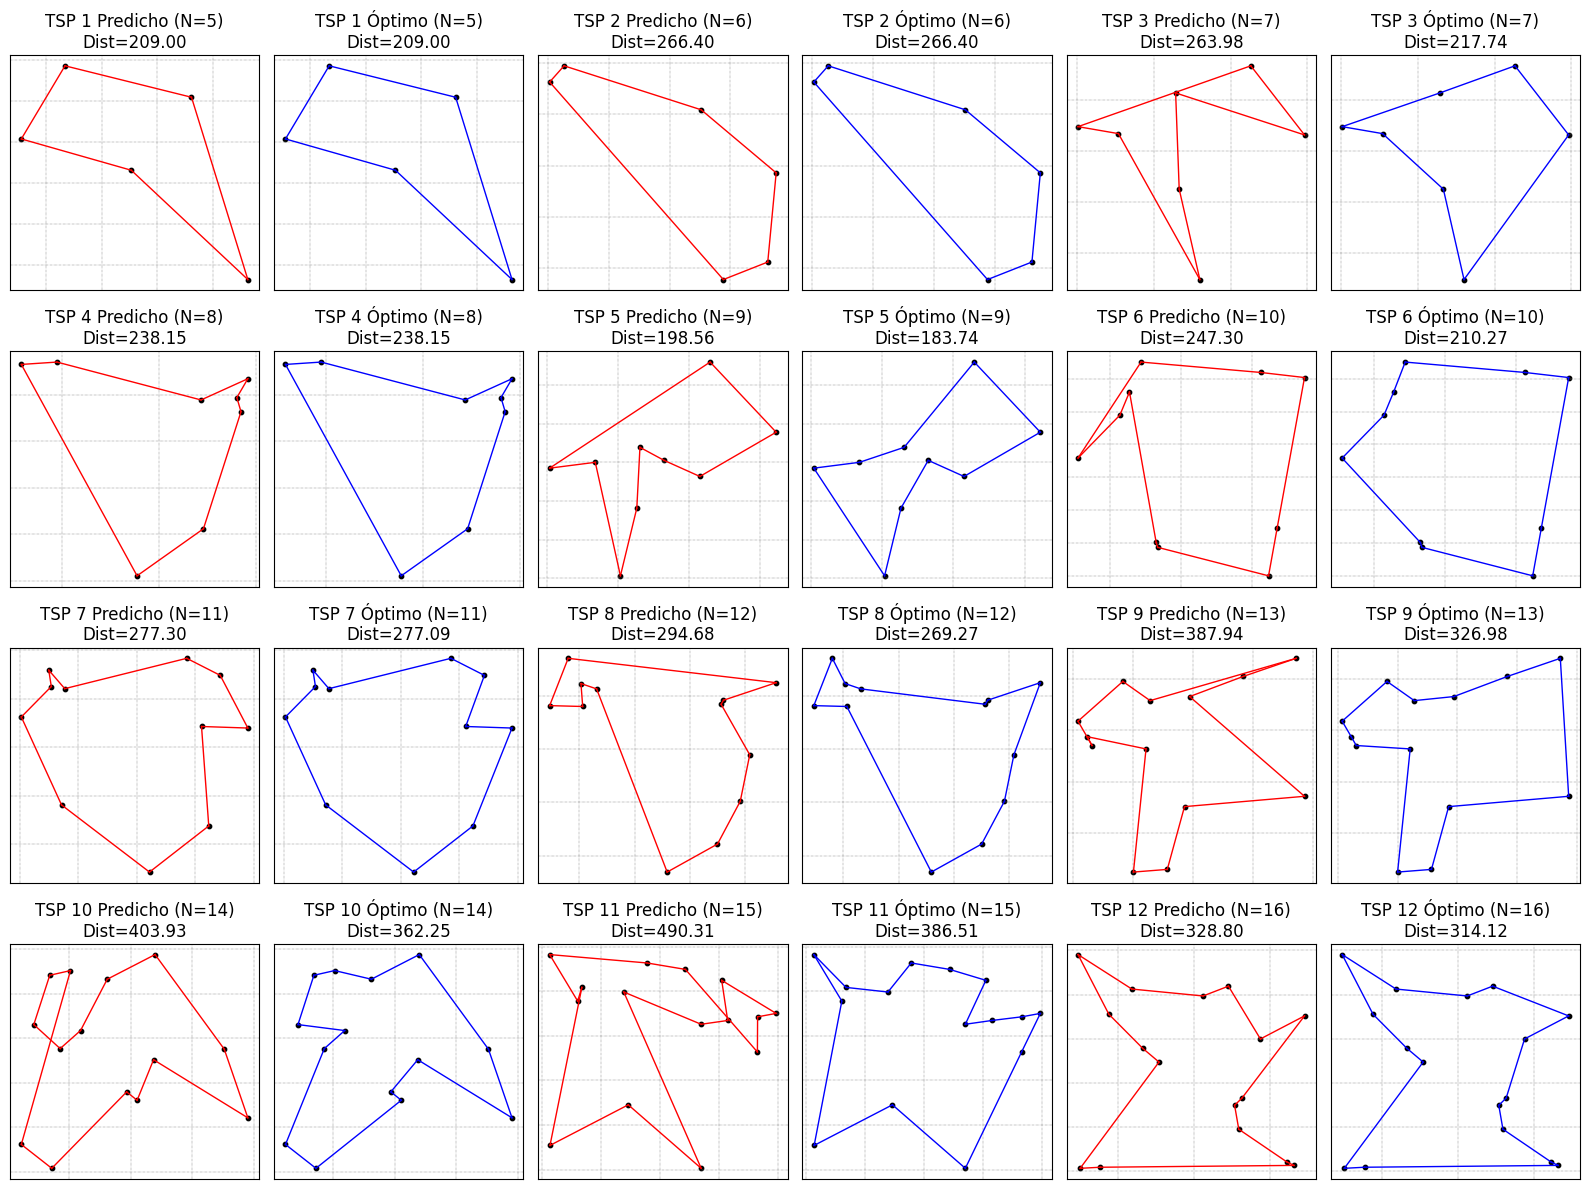

In [35]:
import matplotlib.pyplot as plt

n_instances = len(coords_list)  
n_cols = 6
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))

for idx in range(n_instances):
    row = idx // 3
    col_start = (idx % 3) * 2

    coords = coords_list[idx].numpy()      
    tour_uncross = tour_uncross_list[idx]  
    true_path = true_path_list[idx]        
    pred_distance = pred_dist_list[idx]
    true_distance = true_dist_list[idx]
    num_nodes = num_nodes_list[idx]

    # ——— Subplot Tour Predicho ———
    ax_pred = axes[row, col_start]
    ax_pred.scatter(coords[:, 0], coords[:, 1], color='k', s=10, marker='o')
    for k in range(len(tour_uncross) - 1):
        i = int(tour_uncross[k])
        j = int(tour_uncross[k + 1])
        if 0 <= i < num_nodes and 0 <= j < num_nodes:
            ax_pred.plot(
                [coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color='r', linewidth=1
            )
    # Activar grid gris y fino:
    ax_pred.grid(color='gray', linestyle='-.', linewidth=0.3)
    # Quitar solo etiquetas, no las marcas (para que siga habiendo posiciones de grid):
    ax_pred.tick_params(
        axis='both',
        which='both',
        labelbottom=False,
        labelleft=False,
        length=0
    )
    ax_pred.set_title(
        f"TSP {idx+1} Predicho (N={num_nodes})\nDist={pred_distance:.2f}",
        fontsize=12
    )

    # ——— Subplot Tour Óptimo ———
    ax_true = axes[row, col_start + 1]
    ax_true.scatter(coords[:, 0], coords[:, 1], color='k', s=10, marker='o')
    if true_path[0] != true_path[-1]:
        tp = true_path + [true_path[0]]
    else:
        tp = true_path
    for k in range(len(tp) - 1):
        i = int(tp[k])
        j = int(tp[k + 1])
        if 0 <= i < num_nodes and 0 <= j < num_nodes:
            ax_true.plot(
                [coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color='b', linewidth=1
            )
    # Activar grid gris y fino:
    ax_true.grid(color='gray', linestyle='-.', linewidth=0.3)
    # Quitar solo etiquetas, no las marcas:
    ax_true.tick_params(
        axis='both',
        which='both',
        labelbottom=False,
        labelleft=False,
        length=0
    )
    ax_true.set_title(
        f"TSP {idx+1} Óptimo (N={num_nodes})\nDist={true_distance:.2f}",
        fontsize=12
    )

plt.tight_layout()
plt.show()


**Vamos a probar con un TSP famoso de mayor tamaño, a ver qué solución nos da**

In [37]:
# --- 0) Carga y procesa a280 con FamousTSP ----------------------------
a280 = FamousTSP('TSP_problems/berlin52.tsp', 'TSP_problems/berlin52.opt.tour')

# Extrae coords_list_280 y D_280 como antes
nodes = sorted(a280.coords.keys())  
coords_list = [[a280.coords[i][0], a280.coords[i][1]] for i in nodes]
D_full = np.array(a280.dist_matrix)                # shape (281,281)
D_280 = D_full[1:a280.dimension+1,1:a280.dimension+1]  # recorta fila/columna 0

# (Si tuviste que eliminar duplicados, hazlo aquí,
#  y ajusta coords_list_280 y D_280 en paralelo)

# Usa las versiones finales:
coords_list_280 = coords_list
print(coords_list_280)
dist_mat = D_280
coords = torch.tensor(coords_list_280, dtype=torch.float)  # [N,2]
N = coords.size(0)

# --- 1) Construir grafo completo dirigido ---
edges = [(i, j) for i in range(N) for j in range(N) if i != j]
edge_index  = torch.tensor(edges, dtype=torch.long).t().contiguous()  # [2, E]
edge_attr   = torch.tensor([[dist_mat[i, j]] for i, j in edges], dtype=torch.float)  # [E,1]
edge_weight = edge_attr.clone()

# --- 2) Extraer tour óptimo (lista de nodos) ---
# `a280.tour` es la lista 1-based; la pasamos a 0-based:
tour_1_based = a280.tour
tour_zero_based = [v - 1 for v in tour_1_based]
tour_zero_based.append(tour_zero_based[0])  # cerrar ciclo

# --- 3) Crear objeto Data para PyG ---
batch = torch.zeros(N, dtype=torch.long)  # un solo grafo
data_a280 = Data(
    x=coords,
    edge_index=edge_index,
    edge_attr=edge_attr,
    edge_weight=edge_weight,
    batch=batch,
)

# Añadir atributos extra
data_a280.true_path       = torch.tensor(tour_zero_based, dtype=torch.long)
# Calcula la distancia total del tour a partir de dist_mat
total_dist = sum(dist_mat[tour_zero_based[k], tour_zero_based[k+1]] 
                 for k in range(N))
data_a280.true_distance   = torch.tensor([total_dist], dtype=torch.float)
data_a280.pos_class_weight = ((N*(N-1) - N) / N)  


[[565.0, 575.0], [25.0, 185.0], [345.0, 750.0], [945.0, 685.0], [845.0, 655.0], [880.0, 660.0], [25.0, 230.0], [525.0, 1000.0], [580.0, 1175.0], [650.0, 1130.0], [1605.0, 620.0], [1220.0, 580.0], [1465.0, 200.0], [1530.0, 5.0], [845.0, 680.0], [725.0, 370.0], [145.0, 665.0], [415.0, 635.0], [510.0, 875.0], [560.0, 365.0], [300.0, 465.0], [520.0, 585.0], [480.0, 415.0], [835.0, 625.0], [975.0, 580.0], [1215.0, 245.0], [1320.0, 315.0], [1250.0, 400.0], [660.0, 180.0], [410.0, 250.0], [420.0, 555.0], [575.0, 665.0], [1150.0, 1160.0], [700.0, 580.0], [685.0, 595.0], [685.0, 610.0], [770.0, 610.0], [795.0, 645.0], [720.0, 635.0], [760.0, 650.0], [475.0, 960.0], [95.0, 260.0], [875.0, 920.0], [700.0, 500.0], [555.0, 815.0], [830.0, 485.0], [1170.0, 65.0], [830.0, 610.0], [605.0, 625.0], [595.0, 360.0], [1340.0, 725.0], [1740.0, 245.0]]


In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GNN(
    node_input_dim=2,
    edge_input_dim=1,
    hidden_dim=64,
    decoder="edge_nodes_emb",
    use_edge_weight=True
).to(device)
model.load_state_dict(torch.load(
    "trained_models_ELU/model_8_hd64_lr0.0005_ep32_dec_edge_nodes_emb.pt",
    map_location=device
))
model.eval()

# --- 1) Forward + logits/probs ---
with torch.no_grad():
    logits = model(
        data_a280.x.to(device),
        data_a280.edge_index.to(device),
        data_a280.edge_attr.to(device),
        data_a280.edge_weight.to(device),
        data_a280.batch.to(device)
    )  # [E,1]
probs = torch.sigmoid(logits).view(-1)  # [E]

tour = SolutionAnalysys.tour_from_probs(probs, len(nodes))

uncorner = Opt(coords_list_280)
tour = uncorner.uncross(tour)

# --- 3) Cálculo de métricas usando dist_mat y data_a280.true_distance ---
pred_len = sum(dist_mat[tour[k], tour[k+1]] for k in range(N))
true_len = data_a280.true_distance.item()
opt_gap = (pred_len - true_len) / true_len


# --- 4) Impresión final ---
print("Tour óptimo real:   ", data_a280.true_path.tolist())
print("Tour predicho:      ", tour)
print(f"Longitud real:      {true_len:.2f}")
print(f"Longitud predicha:  {pred_len:.2f}")
print(f"Optimality gap:     {opt_gap*100:.2f}%")

Tour óptimo real:    [0, 48, 31, 44, 18, 40, 7, 8, 9, 42, 32, 50, 10, 51, 13, 12, 46, 25, 26, 27, 11, 24, 3, 5, 14, 4, 23, 47, 37, 36, 39, 38, 35, 34, 33, 43, 45, 15, 28, 49, 19, 22, 29, 1, 6, 41, 20, 16, 2, 17, 30, 21, 0]
Tour predicho:       [0, 17, 25, 15, 27, 14, 26, 42, 7, 13, 5, 11, 4, 12, 9, 3, 50, 1, 51, 10, 32, 8, 2, 24, 18, 40, 23, 47, 37, 39, 36, 38, 44, 46, 19, 35, 34, 33, 31, 48, 45, 43, 30, 49, 22, 28, 29, 41, 6, 20, 16, 21, 0]
Longitud real:      7542.00
Longitud predicha:  23041.00
Optimality gap:     205.50%


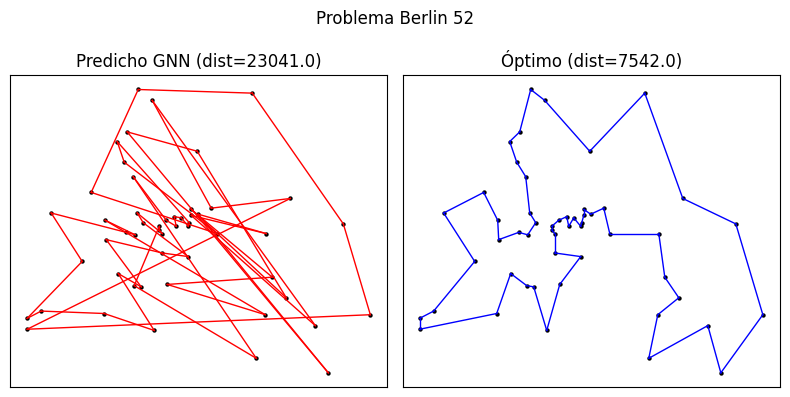

In [40]:
# 6) Visualización comparativa con puntos más pequeños
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle("Problema Berlin 52", fontsize=12)
coords_np = data_a280.x.cpu().numpy()

# Predicho
ax = axes[0]
ax.scatter(coords_np[:,0], coords_np[:,1],
           color='k', s=10, marker='o', linewidths=0)
for a, b in zip(tour[:-1], tour[1:]):
    ax.plot([coords_np[a,0], coords_np[b,0]],
            [coords_np[a,1], coords_np[b,1]],
            c='r', linewidth=1)
ax.set_title(f"Predicho GNN (dist={pred_len:.1f})")
ax.set_xticks([]); ax.set_yticks([])

# Óptimo
ax = axes[1]
ax.scatter(coords_np[:,0], coords_np[:,1], color='k', s=10, marker='o', linewidths=0)
for a, b in zip(data_a280.true_path[:-1], data_a280.true_path[1:]):
    ax.plot([coords_np[a,0], coords_np[b,0]],
            [coords_np[a,1], coords_np[b,1]],
            c='b', linewidth=1)
ax.set_title(f"Óptimo (dist={true_len:.1f})")
ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()